In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [7]:
# 读取训练数据和测试数据
train_data = pd.read_excel('./data/无鸽子笼.xlsx')
test_data = pd.read_excel('./data/鸽子笼.xlsx')

# 提取输入特征和输出标签
train_features = train_data[['外侧干球','压缩机频率','风机频率','冷媒压力2#排气','冷媒压力3#喷焓','冷媒压力4#回气','T3','冷中','辅进','冷媒散热管出口','辅出']].values
train_labels = train_data[['能力', '能效']].values
test_features = test_data[['外侧干球','压缩机频率','风机频率','冷媒压力2#排气','冷媒压力3#喷焓','冷媒压力4#回气','T3','冷中','辅进','冷媒散热管出口','辅出']].values
test_labels =test_data[['能力', '能效']]

In [9]:
# 数据标准化，将特征缩放到0-1的范围内
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)
train_labels = scaler.fit_transform(train_labels)
#test_labels = scaler.transform(test_labels)

In [10]:
# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(train_features, train_labels, test_size=0.2, random_state=80)

# 创建神经网络模型
model = tf.keras.Sequential([
    tf.keras.layers.Dense(7, activation='relu', input_shape=(X_train.shape[1],)),
    
    tf.keras.layers.Dense(train_labels.shape[1])  # 输出层有两个节点，对应能力和能效
])

In [11]:
# 编译模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 训练模型
model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_val, y_val))

# 使用模型进行预测
prediction = model.predict(test_features)
#恢复数据集
predictions = scaler.inverse_transform(prediction)
# 计算预测误差（均方根误差RMSE）
mse = mean_squared_error(test_labels.values, predictions)
rmse = np.sqrt(mse)
print("均方根误差（RMSE）:", rmse)


Epoch 1/1000

14/14 [==============================] - 2s 24ms/step - loss: 3.4092 - val_loss: 3.0474
Epoch 2/1000
14/14 [==============================] - 0s 6ms/step - loss: 2.7955 - val_loss: 2.4102
Epoch 3/1000
14/14 [==============================] - 0s 5ms/step - loss: 2.3436 - val_loss: 1.9846
Epoch 4/1000
14/14 [==============================] - 0s 6ms/step - loss: 2.0320 - val_loss: 1.7097
Epoch 5/1000
14/14 [==============================] - 0s 5ms/step - loss: 1.8177 - val_loss: 1.4881
Epoch 6/1000
14/14 [==============================] - 0s 4ms/step - loss: 1.6405 - val_loss: 1.3223
Epoch 7/1000
14/14 [==============================] - 0s 5ms/step - loss: 1.4937 - val_loss: 1.1909
Epoch 8/1000
14/14 [==============================] - 0s 4ms/step - loss: 1.3709 - val_loss: 1.0707
Epoch 9/1000
14/14 [==============================] - 0s 6ms/step - loss: 1.2679 - val_loss: 0.9680
Epoch 10/1000
14/14 [==============================] - 0s 6ms/step - loss: 1.1815 - val_loss: 0.8

14/14 [==============================] - 0s 7ms/step - loss: 0.3377 - val_loss: 0.2587
Epoch 79/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.3352 - val_loss: 0.2555
Epoch 80/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.3330 - val_loss: 0.2534
Epoch 81/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.3307 - val_loss: 0.2512
Epoch 82/1000
14/14 [==============================] - 0s 8ms/step - loss: 0.3282 - val_loss: 0.2492
Epoch 83/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.3258 - val_loss: 0.2476
Epoch 84/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.3242 - val_loss: 0.2444
Epoch 85/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.3219 - val_loss: 0.2426
Epoch 86/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.3198 - val_loss: 0.2406
Epoch 87/1000
14/14 [==============================] - 0s 8ms/step - loss: 0.3183 - val_loss: 0.2389
Epoc

14/14 [==============================] - 0s 5ms/step - loss: 0.2538 - val_loss: 0.2006
Epoch 159/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.2532 - val_loss: 0.1997
Epoch 160/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.2523 - val_loss: 0.1991
Epoch 161/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.2519 - val_loss: 0.1987
Epoch 162/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.2513 - val_loss: 0.1974
Epoch 163/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.2508 - val_loss: 0.1970
Epoch 164/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.2507 - val_loss: 0.1968
Epoch 165/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.2493 - val_loss: 0.1903
Epoch 166/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.2485 - val_loss: 0.1896
Epoch 167/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.2480 - val_loss: 0.

14/14 [==============================] - 0s 10ms/step - loss: 0.1998 - val_loss: 0.1658
Epoch 239/1000
14/14 [==============================] - 0s 8ms/step - loss: 0.1982 - val_loss: 0.1652
Epoch 240/1000
14/14 [==============================] - 0s 8ms/step - loss: 0.1972 - val_loss: 0.1637
Epoch 241/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.1966 - val_loss: 0.1627
Epoch 242/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.1960 - val_loss: 0.1620
Epoch 243/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1951 - val_loss: 0.1617
Epoch 244/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1950 - val_loss: 0.1624
Epoch 245/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1936 - val_loss: 0.1614
Epoch 246/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.1935 - val_loss: 0.1605
Epoch 247/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.1927 - val_loss: 0

14/14 [==============================] - 0s 4ms/step - loss: 0.1568 - val_loss: 0.1350
Epoch 319/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.1562 - val_loss: 0.1354
Epoch 320/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.1564 - val_loss: 0.1358
Epoch 321/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.1554 - val_loss: 0.1354
Epoch 322/1000
14/14 [==============================] - 0s 8ms/step - loss: 0.1551 - val_loss: 0.1352
Epoch 323/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1546 - val_loss: 0.1357
Epoch 324/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1544 - val_loss: 0.1360
Epoch 325/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.1539 - val_loss: 0.1366
Epoch 326/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.1538 - val_loss: 0.1360
Epoch 327/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.1531 - val_loss: 0.

...

14/14 [==============================] - 0s 6ms/step - loss: 0.0838 - val_loss: 0.1238
Epoch 639/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0838 - val_loss: 0.1242
Epoch 640/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0839 - val_loss: 0.1240
Epoch 641/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0841 - val_loss: 0.1242
Epoch 642/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0840 - val_loss: 0.1240
Epoch 643/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0836 - val_loss: 0.1236
Epoch 644/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0837 - val_loss: 0.1243
Epoch 645/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0840 - val_loss: 0.1240
Epoch 646/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0835 - val_loss: 0.1231
Epoch 647/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0836 - val_loss: 0.

14/14 [==============================] - 0s 6ms/step - loss: 0.0795 - val_loss: 0.1236
Epoch 719/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0797 - val_loss: 0.1237
Epoch 720/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0800 - val_loss: 0.1246
Epoch 721/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0799 - val_loss: 0.1233
Epoch 722/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0801 - val_loss: 0.1257
Epoch 723/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0797 - val_loss: 0.1255
Epoch 724/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0943 - val_loss: 0.1354
Epoch 725/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0834 - val_loss: 0.1328
Epoch 726/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0830 - val_loss: 0.1252
Epoch 727/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0817 - val_loss: 0.

14/14 [==============================] - 0s 8ms/step - loss: 0.0725 - val_loss: 0.1257
Epoch 799/1000
14/14 [==============================] - 0s 9ms/step - loss: 0.0717 - val_loss: 0.1249
Epoch 800/1000
14/14 [==============================] - 0s 7ms/step - loss: 0.0714 - val_loss: 0.1244
Epoch 801/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0713 - val_loss: 0.1241
Epoch 802/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0711 - val_loss: 0.1244
Epoch 803/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0710 - val_loss: 0.1247
Epoch 804/1000
14/14 [==============================] - 0s 6ms/step - loss: 0.0710 - val_loss: 0.1244
Epoch 805/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0708 - val_loss: 0.1247
Epoch 806/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0709 - val_loss: 0.1236
Epoch 807/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0708 - val_loss: 0.

14/14 [==============================] - 0s 5ms/step - loss: 0.0655 - val_loss: 0.1239
Epoch 879/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0653 - val_loss: 0.1231
Epoch 880/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0651 - val_loss: 0.1249
Epoch 881/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0650 - val_loss: 0.1244
Epoch 882/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0667 - val_loss: 0.1236
Epoch 883/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0650 - val_loss: 0.1257
Epoch 884/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0650 - val_loss: 0.1249
Epoch 885/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0651 - val_loss: 0.1231
Epoch 886/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0646 - val_loss: 0.1241
Epoch 887/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0647 - val_loss: 0.

14/14 [==============================] - 0s 10ms/step - loss: 0.0597 - val_loss: 0.1251
Epoch 959/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0597 - val_loss: 0.1254
Epoch 960/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0599 - val_loss: 0.1247
Epoch 961/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0601 - val_loss: 0.1267
Epoch 962/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0600 - val_loss: 0.1251
Epoch 963/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0598 - val_loss: 0.1268
Epoch 964/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0756 - val_loss: 0.1298
Epoch 965/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0679 - val_loss: 0.1295
Epoch 966/1000
14/14 [==============================] - 0s 4ms/step - loss: 0.0645 - val_loss: 0.1252
Epoch 967/1000
14/14 [==============================] - 0s 5ms/step - loss: 0.0617 - val_loss: 0

In [12]:
def r_squared(y_true, y_pred):
    """
    计算R-squared（决定系数）的拟合优度函数。

    参数:
    y_true -- 真实观测值的数组
    y_pred -- 模型预测值的数组

    返回:
    r2 -- R-squared（决定系数）值
    """
    # 计算总平方和（Total Sum of Squares）
    total_sum_of_squares = np.sum((y_true - np.mean(y_true))**2)

    # 计算残差平方和（Residual Sum of Squares）
    residual_sum_of_squares = np.sum((y_true - y_pred)**2)

    # 计算R-squared（决定系数）
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)

    return r2




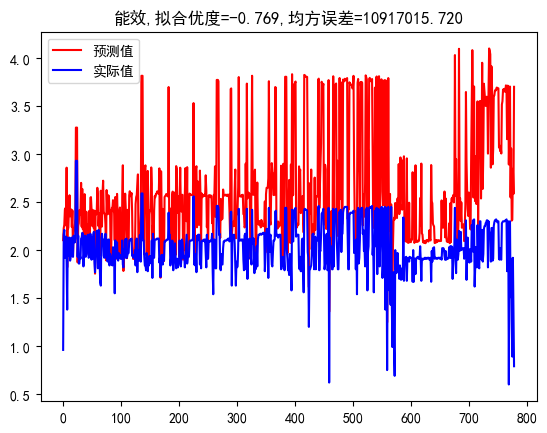

In [17]:
#预测数据索引
index=1
xarry=np.arange(predictions.shape[0])
# 设置中文字体
plt.rcParams['font.family'] = ['SimHei']
plt.plot(xarry,predictions[:,index],label='预测值',c='r')
plt.plot(xarry,test_labels.values[:,index],label="实际值",c='b')
r2=r_squared(predictions[:,index],test_labels.values[:,index])
plt.title(test_labels.columns[index]+',拟合优度={:.3f}'.format(r2)+',均方误差={:.3f}'.format(mse))
plt.legend()
plt.show()

D:\zhonglf13\Miniconda3\envs\py38\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


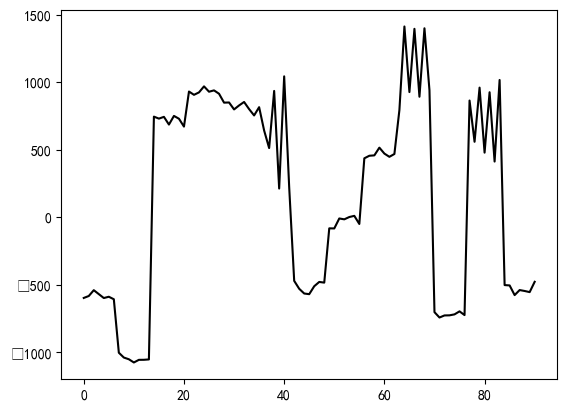

In [22]:
bizhi=(predictions[:,index]-test_labels.values[:,index])
plt.plot(xarry,bizhi,label="实际值",c='black')
plt.show()